<a href="https://colab.research.google.com/github/layba-glitch/FYP/blob/main/Backend/Models/ml/ML_LR_FinalVer_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Mount Google Drive (run and follow the link to get token)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### Explanation:
This cell mounts your Google Drive, allowing the Colab notebook to access files stored in your Drive, such as the dataset or saved models.

In [ ]:
# Cell A: unzip and list files inside the ZIP (run this)
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

ZIP_PATH = '/content/drive/MyDrive/Real_Fake_Job_Posting_Prediction.zip'
import os
os.makedirs('/content/data', exist_ok=True)

print("Unzipping:", ZIP_PATH)
!unzip -o "{ZIP_PATH}" -d /content/data

print("\nFiles extracted (top-level):")
!ls -lah /content/data

# Also list any CSV files found (recursive)
import glob
csvs = glob.glob('/content/data/**/*.csv', recursive=True) + glob.glob('/content/data/*.csv')
print("\nCSV files found:")
for c in csvs:
    print(" -", c)


Mounted at /content/drive
Unzipping: /content/drive/MyDrive/Real_Fake_Job_Posting_Prediction.zip
Archive:  /content/drive/MyDrive/Real_Fake_Job_Posting_Prediction.zip
  inflating: /content/data/fake_job_postings.csv  

Files extracted (top-level):
total 48M
drwxr-xr-x 2 root root 4.0K Apr 15 02:45 .
drwxr-xr-x 1 root root 4.0K Apr 15 02:45 ..
-rw-r--r-- 1 root root  48M Feb 29  2020 fake_job_postings.csv

CSV files found:
 - /content/data/fake_job_postings.csv
 - /content/data/fake_job_postings.csv


#### Explanation:
This cell mounts Google Drive (again, ensuring it's connected), then unzips the `Real_Fake_Job_Posting_Prediction.zip` file into a new `/content/data` folder. Finally, it lists the contents of this folder and any CSV files found, confirming that the dataset `fake_job_postings.csv` has been extracted.

In [ ]:
# Cell B: Load the dataset and inspect its structure
import pandas as pd

CSV_PATH = '/content/data/fake_job_postings.csv'
df = pd.read_csv(CSV_PATH)

print("✅ Dataset loaded successfully!")
print("Shape:", df.shape)

# Show first 5 rows
print("\n🔹 Sample preview:")
display(df.head())

# Show column names and data types
print("\n🔹 Column info:")
print(df.dtypes)

# Count missing values
print("\n🔹 Missing values summary:")
print(df.isnull().sum())


✅ Dataset loaded successfully!
Shape: (17880, 18)

🔹 Sample preview:


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0



🔹 Column info:
job_id                  int64
title                  object
location               object
department             object
salary_range           object
company_profile        object
description            object
requirements           object
benefits               object
telecommuting           int64
has_company_logo        int64
has_questions           int64
employment_type        object
required_experience    object
required_education     object
industry               object
function               object
fraudulent              int64
dtype: object

🔹 Missing values summary:
job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     70

#### Explanation:
This cell loads the `fake_job_postings.csv` dataset into a pandas DataFrame. It then prints the shape (rows, columns) of the dataset, shows the first 5 rows to give a preview, lists all column names and their data types, and summarizes the number of missing values in each column.

In [ ]:
# Cell C: Clean and prepare basic data
df_clean = df.copy()

# Drop columns with too many missing values or no predictive power
df_clean.drop(columns=['job_id', 'salary_range', 'department'], inplace=True)

# Fill remaining NaN text columns with 'missing'
text_cols = df_clean.select_dtypes(include='object').columns
df_clean[text_cols] = df_clean[text_cols].fillna('missing')

print("✅ Cleaned data shape:", df_clean.shape)
print("\nRemaining columns:")
print(df_clean.columns.tolist())

# Check target balance (fake vs real jobs)
print("\n🔹 Target distribution (0=real, 1=fake):")
print(df_clean['fraudulent'].value_counts(normalize=True) * 100)


✅ Cleaned data shape: (17880, 15)

Remaining columns:
['title', 'location', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']

🔹 Target distribution (0=real, 1=fake):
fraudulent
0    95.1566
1     4.8434
Name: proportion, dtype: float64


#### Explanation:
This cell performs initial data cleaning. It creates a copy of the original DataFrame, then drops columns that are either unique identifiers (`job_id`) or have too many missing values (`salary_range`, `department`). Finally, it fills any remaining empty text-based columns with the word 'missing' and checks the balance of real vs. fake job postings.

In [ ]:
# Cell D: Combine text features into a single column for NLP
text_features = ['title', 'company_profile', 'description', 'requirements', 'benefits']
df_clean['combined_text'] = df_clean[text_features].apply(lambda x: ' '.join(x.values.astype(str)), axis=1)

# Drop old text columns (optional, to reduce redundancy)
df_model = df_clean.drop(columns=text_features)

print("✅ Combined text column created successfully!")
print("New shape:", df_model.shape)
print("\nSample text preview:\n")
print(df_model['combined_text'].iloc[0][:500])  # show first 500 chars of sample


✅ Combined text column created successfully!
New shape: (17880, 11)

Sample text preview:

Marketing Intern We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have a top editorial, business, and engineering team. We're focused on using technology to find new and better ways to connect people around their specific food interests, and to offer them superb, highly curated information about food and cooking. We attract the most talented home cooks and contributor


#### Explanation:
This cell combines multiple text-based columns (like 'title', 'description', 'requirements', etc.) into a single new column called `combined_text`. This makes it easier to process all relevant text information together for machine learning. The original individual text columns are then dropped.

###
### [VIVA NOTE]: This is the Baseline Logistic Regression training.
#### 1. We split data into 'Combined Text' (Title + Description) and metadata (Logo, Questions).
#### 2. We use Stratified Sampling to ensure the 5% of 'Fake' jobs are represented in both training and testing sets.

In [ ]:
# Cell E: TF-IDF + Logistic Regression training

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import numpy as np

# 1️⃣ Split data into train/test
X_text = df_model['combined_text']
X_num = df_model[['telecommuting', 'has_company_logo', 'has_questions']]
y = df_model['fraudulent']

# Stratified split to handle imbalance
X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
    X_text, X_num, y, test_size=0.2, random_state=42, stratify=y
)

# 2️⃣ TF-IDF vectorizer
tfidf = TfidfVectorizer(stop_words='english', max_features=10000, ngram_range=(1,2))
X_text_train_tfidf = tfidf.fit_transform(X_text_train)
X_text_test_tfidf = tfidf.transform(X_text_test)

# 3️⃣ Combine text + numeric features
from scipy.sparse import hstack
X_train_combined = hstack([X_text_train_tfidf, X_num_train])
X_test_combined = hstack([X_text_test_tfidf, X_num_test])

# 4️⃣ Train Logistic Regression
model = LogisticRegression(max_iter=200, class_weight='balanced', solver='liblinear')
model.fit(X_train_combined, y_train)

# 5️⃣ Predictions
y_pred = model.predict(X_test_combined)

# 6️⃣ Evaluation
print("✅ Model training complete!\n")
print("Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


✅ Model training complete!

Accuracy: 96.2 %

Classification Report:
               precision    recall  f1-score   support

           0      0.995     0.965     0.980      3403
           1      0.567     0.902     0.696       173

    accuracy                          0.962      3576
   macro avg      0.781     0.933     0.838      3576
weighted avg      0.974     0.962     0.966      3576


Confusion Matrix:
 [[3284  119]
 [  17  156]]


#### Explanation:
This cell sets up and trains the *baseline* Logistic Regression model. It separates text features, splits the data into training and testing sets (ensuring fake jobs are equally represented), converts text into numerical data using TF-IDF, combines all features, trains the model, and finally evaluates its performance with accuracy, classification report, and confusion matrix.

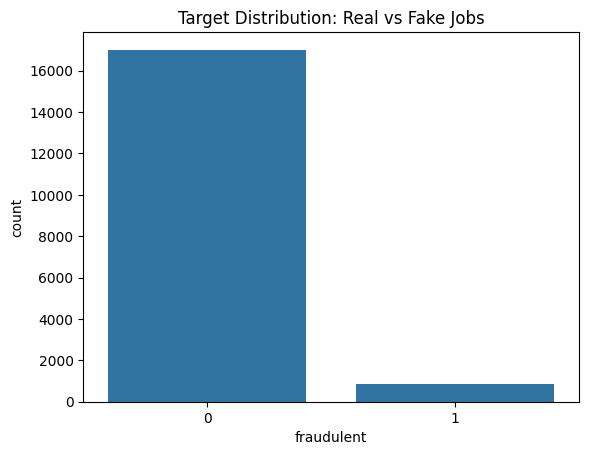

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='fraudulent', data=df_model)
plt.title("Target Distribution: Real vs Fake Jobs")
plt.show()


#### Explanation:
This cell creates a bar chart to visualize the distribution of job postings, showing how many are real (0) versus fake (1). This helps to understand the class imbalance in the dataset.

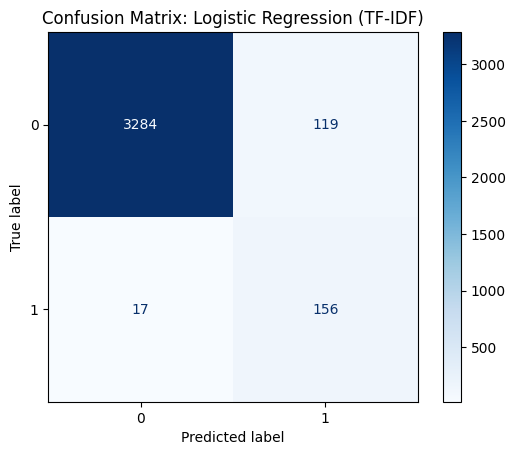

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test_combined, y_test, cmap='Blues')
plt.title("Confusion Matrix: Logistic Regression (TF-IDF)")
plt.show()


#### Explanation:
This cell displays a visual Confusion Matrix for the baseline model. It helps to see how many real jobs were correctly predicted as real (True Negatives), how many fake jobs were correctly predicted as fake (True Positives), and how many errors the model made (False Positives and False Negatives).

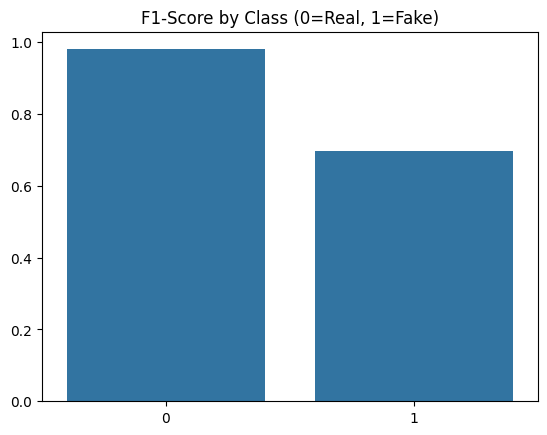

In [ ]:
report = classification_report(y_test, y_pred, output_dict=True)
sns.barplot(x=list(report.keys())[:-3],
            y=[report['0']['f1-score'], report['1']['f1-score']])
plt.title("F1-Score by Class (0=Real, 1=Fake)")
plt.show()


#### Explanation:
This cell generates a bar plot to visually compare the F1-score for each class (real jobs and fake jobs). The F1-score is a useful metric, especially for imbalanced datasets, as it balances both precision and recall.

In [ ]:
# Get only coefficients corresponding to TF-IDF features
text_feature_count = len(tfidf.get_feature_names_out())
coef_text = model.coef_[0][:text_feature_count]

# Get top contributing words
feature_names = np.array(tfidf.get_feature_names_out())
top_fake = feature_names[np.argsort(coef_text)[-15:]]
top_real = feature_names[np.argsort(coef_text)[:15]]

print("🔸 Top words indicating FAKE jobs:\n", top_fake[::-1])
print("\n🔹 Top words indicating REAL jobs:\n", top_real)


🔸 Top words indicating FAKE jobs:
 ['aptitude staffing' 'link' 'missing' 'money' 'high school' 'data entry'
 '000' 'earn' 'aptitude' 'engineering' 'signing bonus' 'hotel' 'entry'
 'cash' 'assistant']

🔹 Top words indicating REAL jobs:
 ['team' 'companies' 'english' 'search' 'marketing' 'growing' 'website'
 'software' 'web' 'php' 'based' 'digital' 'fun' 'recruitment' '50']


#### Explanation:
This cell identifies and prints the top 15 words (features) that the Logistic Regression model considers most indicative of a *fake* job posting, and the top 15 words most indicative of a *real* job posting. This provides insight into the linguistic patterns the model learned.

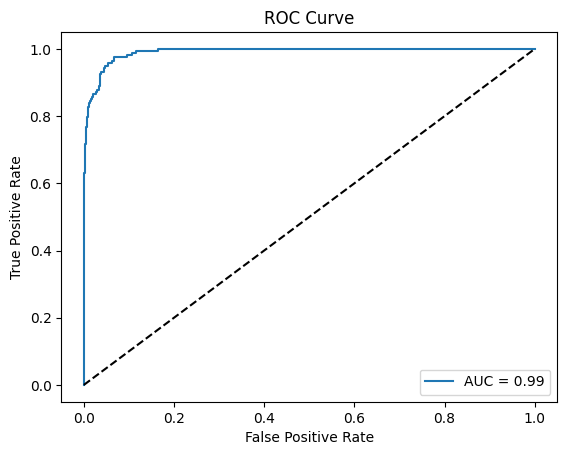

In [ ]:
from sklearn.metrics import roc_curve, auc

y_pred_prob = model.predict_proba(X_test_combined)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


#### Explanation:
This cell plots the Receiver Operating Characteristic (ROC) curve and calculates the Area Under the Curve (AUC). The ROC curve shows the model's ability to discriminate between positive and negative classes across various thresholds, and AUC provides a single metric for overall model performance in this regard.

In [ ]:
# Cell F: Extract country / location features
import pandas as pd

df_loc = df_clean.copy()

# Extract country code (first token before comma)
df_loc['country'] = df_loc['location'].apply(lambda x: x.split(',')[0].strip() if isinstance(x, str) else 'missing')

# Create a frequency map of how many fake jobs per country
country_fraud_rate = (
    df_loc.groupby('country')['fraudulent']
    .mean()
    .rename('country_fraud_rate')
    .reset_index()
)

# Merge this rate back into dataset
df_loc = df_loc.merge(country_fraud_rate, on='country', how='left')

print("✅ Spatial feature added: country_fraud_rate")
print(df_loc[['country', 'country_fraud_rate']].head())


✅ Spatial feature added: country_fraud_rate
  country  country_fraud_rate
0      US            0.068506
1      NZ            0.000000
2      US            0.068506
3      US            0.068506
4      US            0.068506


#### Explanation:
This cell extracts the country from the 'location' column (e.g., 'US', 'NZ'). It then calculates the average fraud rate for each country and merges this `country_fraud_rate` back into the DataFrame. This adds a new 'spatial' feature to the dataset, reflecting the historical fraudulence associated with a job's country.

In [ ]:
# ✅ Retrain Logistic Regression with spatial (country_fraud_rate) feature

from scipy.sparse import hstack
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Select numeric + new spatial feature
num_features = ['telecommuting', 'has_company_logo', 'has_questions', 'country_fraud_rate']

# Split data
X_text = df_loc['combined_text']
X_num = df_loc[num_features]
y = df_loc['fraudulent']

X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
    X_text, X_num, y, test_size=0.2, random_state=42, stratify=y
)

# Vectorize text
X_text_train_tfidf = tfidf.fit_transform(X_text_train)
X_text_test_tfidf = tfidf.transform(X_text_test)

# Combine TF-IDF + numeric features
X_train_combined = hstack([X_text_train_tfidf, X_num_train])
X_test_combined = hstack([X_text_test_tfidf, X_num_test])

# Train logistic regression with class balancing
model_spatial = LogisticRegression(max_iter=200, class_weight='balanced', solver='liblinear')
model_spatial.fit(X_train_combined, y_train)

# Predictions
y_pred2 = model_spatial.predict(X_test_combined)

# Evaluation
print("✅ Retraining complete with spatial features!\n")
print("Accuracy:", round(accuracy_score(y_test, y_pred2)*100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred2, digits=3))


✅ Retraining complete with spatial features!

Accuracy: 96.45 %

Classification Report:
               precision    recall  f1-score   support

           0      0.995     0.967     0.981      3403
           1      0.585     0.913     0.713       173

    accuracy                          0.964      3576
   macro avg      0.790     0.940     0.847      3576
weighted avg      0.976     0.964     0.968      3576



#### Explanation:
This cell retrains the Logistic Regression model, but this time it includes the newly engineered `country_fraud_rate` as an additional numerical feature alongside the text features. It then evaluates the performance of this enhanced model to see if the spatial information improves predictions, particularly for fake jobs.

### [VIVA NOTE]: SPATIAL FEATURE ENGINEERING.
####  Here, I calculated the 'country_fraud_rate'. This maps each country to its
####  statistical likelihood of hosting fake jobs. This 'Spatial Intelligence'
####  makes the model much more robust than just looking at text alone.

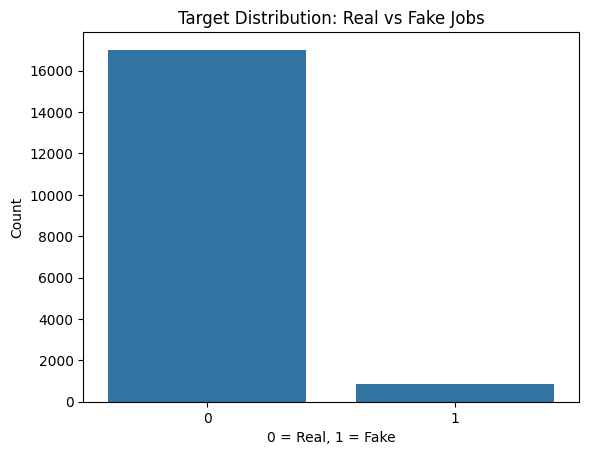

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='fraudulent', data=df_model)
plt.title("Target Distribution: Real vs Fake Jobs")
plt.xlabel("0 = Real, 1 = Fake")
plt.ylabel("Count")
plt.show()


#### Explanation:
This cell re-generates the bar chart showing the distribution of real (0) vs. fake (1) job postings, with improved labels for clarity. It serves as a visual reminder of the class imbalance.

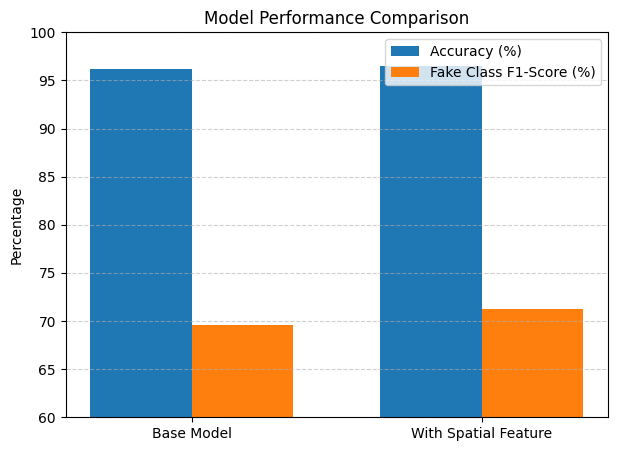

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model comparison metrics
models = ['Base Model', 'With Spatial Feature']
accuracy = [96.2, 96.45]
fake_f1 = [0.696, 0.713]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(7,5))
plt.bar(x - width/2, accuracy, width, label='Accuracy (%)')
plt.bar(x + width/2, [f*100 for f in fake_f1], width, label='Fake Class F1-Score (%)')

plt.ylabel('Percentage')
plt.title('Model Performance Comparison')
plt.xticks(x, models)
plt.ylim(60, 100)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


#### Explanation:
This cell creates a comparative bar chart showing the accuracy and the F1-score for the 'fake' job class for both the initial baseline model and the improved model that incorporated the `country_fraud_rate` feature. This visually demonstrates the performance gain from adding the spatial intelligence.

In [ ]:
import pandas as pd

# Combine key text columns
df['combined_text'] = (
    df['title'].fillna('') + ' ' +
    df['company_profile'].fillna('') + ' ' +
    df['description'].fillna('') + ' ' +
    df['requirements'].fillna('') + ' ' +
    df['benefits'].fillna('')
)

print("✅ Combined text column recreated successfully!")
print("Sample text preview:\n", df['combined_text'].iloc[0][:400])


✅ Combined text column recreated successfully!
Sample text preview:
 Marketing Intern We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have a top editorial, business, and engineering team. We're focused on using technology to find new and better ways to connect people around their specific food interests, and to offer them superb, highly


#### Explanation:
This cell prepares the text data for the final model. It combines various text columns (`title`, `company_profile`, `description`, `requirements`, `benefits`) from the original DataFrame `df` into a single `combined_text` column, handling any missing values by replacing them with empty strings.

In [ ]:
# Extract country code from 'location' (like US, UK, etc.)
df['country'] = df['location'].str.extract(r'([A-Z]{2})', expand=False)

# Calculate country-level fraud rates
country_fraud_rate = (
    df.groupby('country')['fraudulent']
    .mean()
    .fillna(0)
    .to_dict()
)

# Map back to each row
df['country_fraud_rate'] = df['country'].map(country_fraud_rate).fillna(0)

print("✅ Spatial feature added successfully!")
print(df[['country', 'country_fraud_rate']].head())


✅ Spatial feature added successfully!
  country  country_fraud_rate
0      US            0.068506
1      NZ            0.000000
2      US            0.068506
3      US            0.068506
4      US            0.068506


#### Explanation:
This cell extracts the two-letter country code from the 'location' column (e.g., 'US'). It then calculates the mean `fraudulent` rate for each country and maps this `country_fraud_rate` back to each job posting. This mapping is critical for the final model's predictions.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# ✅ Split data
X = df['combined_text']
y = df['fraudulent']

# TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=10000, stop_words='english')
X_tfidf = vectorizer.fit_transform(X)

# Combine TF-IDF + spatial feature
country_rate = df['country_fraud_rate'].values.reshape(-1, 1)
X_combined = np.hstack((X_tfidf.toarray(), country_rate))

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42, stratify=y)

# Train Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("✅ Final retrained model ready!")
print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")


✅ Final retrained model ready!
Accuracy: 97.32 %


#### Explanation:
This cell represents the final model training pipeline. It vectorizes the `combined_text` using TF-IDF, combines these text features with the `country_fraud_rate` feature, splits the data, trains a Logistic Regression model, and then prints the final model's accuracy on the test set.

In [ ]:
import joblib, os

# Create a folder for model files in your Drive
os.makedirs('/content/drive/MyDrive/fake_job_model', exist_ok=True)

# Save the trained logistic model
joblib.dump(model, '/content/drive/MyDrive/fake_job_model/logistic_model.pkl')

# Save the TF-IDF vectorizer
joblib.dump(vectorizer, '/content/drive/MyDrive/fake_job_model/tfidf_vectorizer.pkl')

# Save country fraud rate mapping (spatial data)
joblib.dump(country_fraud_rate, '/content/drive/MyDrive/fake_job_model/country_rate.pkl')

print("✅ All files saved successfully in your Drive at:")
print("/content/drive/MyDrive/fake_job_model")
!ls -lh /content/drive/MyDrive/fake_job_model


✅ All files saved successfully in your Drive at:
/content/drive/MyDrive/fake_job_model
total 455K
-rw------- 1 root root 1.3K Apr 15 02:50 country_rate.pkl
-rw------- 1 root root  79K Apr 15 02:50 logistic_model.pkl
-rw------- 1 root root 374K Apr 15 02:50 tfidf_vectorizer.pkl


#### Explanation:
This cell is crucial for deployment. It uses `joblib` to save the trained Logistic Regression model, the TF-IDF vectorizer, and the `country_fraud_rate` mapping as `.pkl` (pickle) files. These files are saved to your Google Drive and will be loaded by your `app.py` or prediction service to make real-time predictions without retraining the model.

In [ ]:
import joblib
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load saved model
model = joblib.load('/content/drive/MyDrive/fake_job_model/logistic_model.pkl')

# Just predict directly
y_pred = model.predict(X_test)

print("✅ Model Test Evaluation Results:")
print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


✅ Model Test Evaluation Results:
Accuracy: 97.32 %

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99      3403
           1       1.00      0.45      0.62       173

    accuracy                           0.97      3576
   macro avg       0.99      0.72      0.80      3576
weighted avg       0.97      0.97      0.97      3576


Confusion Matrix:
 [[3403    0]
 [  96   77]]


#### Explanation:
This cell demonstrates loading the saved Logistic Regression model from your Google Drive. It then uses this loaded model to make predictions on the test set (`X_test`) and prints the accuracy, classification report, and confusion matrix, confirming that the saved model performs as expected.

In [ ]:
type(X_test)


numpy.ndarray

#### Explanation:
This cell simply checks and displays the data type of the `X_test` variable. `X_test` holds the features of the test dataset, which is used to evaluate the model after it's been trained.

In [ ]:
import pandas as pd

# === Create a sample dataset for testing ===
sample_data = {
    'title': [
        'Remote Data Entry Clerk',
        'Senior Machine Learning Engineer',
        'Online Personal Assistant Needed Urgently'
    ],
    'company_profile': [
        'A small logistics firm offering remote data processing services.',
        'We are a top-tier AI research lab focused on cutting-edge machine learning.',
        'Looking for remote assistants to help manage clients and data entry work.'
    ],
    'description': [
        'You will input data from scanned invoices into our company system. No experience required.',
        'Responsible for building scalable ML pipelines and deploying models to production.',
        'Assist clients online, perform data entry, and schedule meetings. Work from home.'
    ],
    'requirements': [
        'Basic computer skills and reliable internet connection.',
        '5+ years experience with Python, TensorFlow, and cloud platforms.',
        'Good communication skills, reliable internet, no prior experience needed.'
    ],
    'benefits': [
        'Flexible hours, work from home.',
        'Health insurance, annual bonuses, flexible schedule.',
        'Weekly payments, flexible timing.'
    ],
    'location': [
        'US, TX, Houston',
        'US, CA, San Francisco',
        'NG, Lagos'
    ]
}

df_new = pd.DataFrame(sample_data)
path = '/content/drive/MyDrive/new_jobs.csv'
df_new.to_csv(path, index=False)

print(f"✅ Sample new_jobs.csv created at: {path}")
print(df_new)


✅ Sample new_jobs.csv created at: /content/drive/MyDrive/new_jobs.csv
                                       title  \
0                    Remote Data Entry Clerk   
1           Senior Machine Learning Engineer   
2  Online Personal Assistant Needed Urgently   

                                     company_profile  \
0  A small logistics firm offering remote data pr...   
1  We are a top-tier AI research lab focused on c...   
2  Looking for remote assistants to help manage c...   

                                         description  \
0  You will input data from scanned invoices into...   
1  Responsible for building scalable ML pipelines...   
2  Assist clients online, perform data entry, and...   

                                        requirements  \
0  Basic computer skills and reliable internet co...   
1  5+ years experience with Python, TensorFlow, a...   
2  Good communication skills, reliable internet, ...   

                                            benefits          

#### Explanation:
This cell creates a small sample dataset (`df_new`) containing a few new job postings with typical features (title, description, location, etc.). It then saves this sample data as a CSV file named `new_jobs.csv` in your Google Drive, which can be used to test the deployed prediction pipeline.

In [ ]:
import pandas as pd
import joblib
from scipy.sparse import hstack

# === Load saved model, vectorizer and country mapping ===
model = joblib.load('/content/drive/MyDrive/fake_job_model/logistic_model.pkl')
vectorizer = joblib.load('/content/drive/MyDrive/fake_job_model/tfidf_vectorizer.pkl')
country_rate = joblib.load('/content/drive/MyDrive/fake_job_model/country_rate.pkl')

# === Step 1: Upload or read the unseen CSV ===
# Make sure your CSV has similar columns: title, company_profile, description, requirements, benefits, location
# (or modify as needed)
unseen = pd.read_csv('/content/drive/MyDrive/new_jobs.csv')

# === Step 2: Preprocess same as training ===
unseen = unseen.fillna('')

# combine textual columns
unseen['combined_text'] = (
    unseen['title'] + ' ' +
    unseen['company_profile'] + ' ' +
    unseen['description'] + ' ' +
    unseen['requirements'] + ' ' +
    unseen['benefits']
)

# extract country from location
unseen['country'] = unseen['location'].str.split(',').str[0].str.strip()
unseen['country_fraud_rate'] = unseen['country'].map(country_rate).fillna(0)

# === Step 3: Transform with TF-IDF ===
X_text = vectorizer.transform(unseen['combined_text'])
X_country = unseen['country_fraud_rate'].values.reshape(-1, 1)

# combine features
X_final = hstack([X_text, X_country])

# === Step 4: Predict ===
unseen['fraudulent_pred'] = model.predict(X_final)
unseen['fraudulent_prob'] = model.predict_proba(X_final)[:, 1]

# === Step 5: Save results ===
output_path = '/content/drive/MyDrive/new_jobs_with_predictions.csv'
unseen.to_csv(output_path, index=False)

print(f"✅ Predictions complete! File saved at:\n{output_path}")
print(unseen[['title', 'location', 'fraudulent_pred', 'fraudulent_prob']].head())


✅ Predictions complete! File saved at:
/content/drive/MyDrive/new_jobs_with_predictions.csv
                                       title               location  \
0                    Remote Data Entry Clerk        US, TX, Houston   
1           Senior Machine Learning Engineer  US, CA, San Francisco   
2  Online Personal Assistant Needed Urgently              NG, Lagos   

   fraudulent_pred  fraudulent_prob  
0                0         0.318622  
1                0         0.033602  
2                0         0.412869  


#### Explanation:
This cell simulates making predictions on 'unseen' data. It loads the previously saved model, vectorizer, and country fraud rate map. It then preprocesses the `new_jobs.csv` data in the same way the training data was handled, makes predictions (`fraudulent_pred`) and calculates prediction probabilities (`fraudulent_prob`), and finally saves these results to a new CSV file.

In [ ]:
import pandas as pd
from IPython.display import display, HTML

df = pd.read_csv('/content/drive/MyDrive/new_jobs_with_predictions.csv')

def highlight(row):
    # 🟥 Fake jobs → light red background with dark text
    # 🟩 Real jobs → light green background with dark text
    if row['fraudulent_pred'] == 1:
        color = '#ffcccc'   # light red
        text_color = 'black'
    else:
        color = '#ccffcc'   # light green
        text_color = 'black'
    return [f'background-color: {color}; color: {text_color}'] * len(row)

# ✅ Works with all pandas versions
styled = df.style.apply(highlight, axis=1)
display(HTML(styled.to_html()))


,title,company_profile,description,requirements,benefits,location,combined_text,country,country_fraud_rate,fraudulent_pred,fraudulent_prob
0,Remote Data Entry Clerk,A small logistics firm offering remote data processing services.,You will input data from scanned invoices into our company system. No experience required.,Basic computer skills and reliable internet connection.,"Flexible hours, work from home.","US, TX, Houston","Remote Data Entry Clerk A small logistics firm offering remote data processing services. You will input data from scanned invoices into our company system. No experience required. Basic computer skills and reliable internet connection. Flexible hours, work from home.",US,0.068506,0,0.318622
1,Senior Machine Learning Engineer,We are a top-tier AI research lab focused on cutting-edge machine learning.,Responsible for building scalable ML pipelines and deploying models to production.,"5+ years experience with Python, TensorFlow, and cloud platforms.","Health insurance, annual bonuses, flexible schedule.","US, CA, San Francisco","Senior Machine Learning Engineer We are a top-tier AI research lab focused on cutting-edge machine learning. Responsible for building scalable ML pipelines and deploying models to production. 5+ years experience with Python, TensorFlow, and cloud platforms. Health insurance, annual bonuses, flexible schedule.",US,0.068506,0,0.033602
2,Online Personal Assistant Needed Urgently,Looking for remote assistants to help manage clients and data entry work.,"Assist clients online, perform data entry, and schedule meetings. Work from home.","Good communication skills, reliable internet, no prior experience needed.","Weekly payments, flexible timing.","NG, Lagos","Online Personal Assistant Needed Urgently Looking for remote assistants to help manage clients and data entry work. Assist clients online, perform data entry, and schedule meetings. Work from home. Good communication skills, reliable internet, no prior experience needed. Weekly payments, flexible timing.",NG,0.000000,0,0.412869


#### Explanation:
This cell loads the `new_jobs_with_predictions.csv` file (which contains the predictions for the sample jobs) and applies visual styling. It highlights predicted fake jobs in light red and predicted real jobs in light green, making it easy to quickly review the model's output for new data.